# Section 1 -- Import All Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# -- Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# -- Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -- Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,precision_recall_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

## Section 2 - Loading and cleaning the dataset

Applying all cleaning steps identified in the EDA notebook:

* Drop **customerId** - no predictive value
* Drop **gender** and **PhoneService** (chi_square p-values were 0.49 and 0.35 - not statistically satisfied)
* Fix TotalCharges dtype
* Drop tenure == 0 rows (brand-new customers with no data)


In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df = df.drop(['customerID', 'gender', 'PhoneService'], axis=1)
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)

print("Dropped customerID, gender and PhoneService")
print("New shape:", df.shape)

Dropped customerID, gender and PhoneService
New shape: (7032, 18)


## Section3 - Feature Engineering

Creating **tenure_group** from EDA insight:

* New(0-12 months) -> ~48% churn
* Mid(13-48 months) -> ~23% churn
* Loyal(49-72 months) -> ~8% churn

In [3]:
bins = [0, 12, 48, 72]
labels = ['New', 'Mid', 'Loyal']

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

## Section 4 - Encoding

### 4.1 -- Replace "No internet/phone service" -> "No"

These are just sub-categories of "No" -- collapsing them simplifies encoding.

### 4.2 -- Ordinal Encode tenure_group 

New=0, Mid=1, Loyal=2 preserves the natural order.

### 4.3 -- Binary map Yes/No columns -> 1/0

### 4.4 -- One-hot encode multi-category columns

using **drop_first=True** to avoid thedummy variable trap (multicollinearity issue in Logistic Regression).

### 4.5 -- Encode target (Churn)

In [4]:
# 4.1 --Replacing

service_Cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df[service_Cols] = df[service_Cols].replace({'No phone service': 'No', 'No internet service': 'No'})

# 4.2 -- Ordinal Encoding
df['tenure_group'] = df['tenure_group'].map({'New':0, 'Mid':1, 'Loyal':2})
df['tenure_group'] = df['tenure_group'].astype(int)

# 4.3 -- Binary Mapping
binary_cols = ['Partner','Dependents','PaperlessBilling',
               'OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','MultipleLines']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4.4 -- One hot Encoding Multi category columns

df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'],drop_first=True, dtype=int)

## 4.5 -- Encode target 

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [5]:
df.head(5)

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,TotalCharges,Churn,tenure_group,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,0,0,0,...,29.85,0,0,0,0,0,0,0,1,0
1,0,0,0,34,0,1,0,1,0,0,...,1889.50,0,1,0,0,1,0,0,0,1
2,0,0,0,2,0,1,1,0,0,0,...,108.15,1,0,0,0,0,0,0,0,1
3,0,0,0,45,0,1,0,1,1,0,...,1840.75,0,1,0,0,1,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,...,151.65,1,0,1,0,0,0,0,1,0


## Section 5 -- Train_Test_Split

* Using **stratify=y** to preserve the 73/27 churn ratio in both splits.
This is important for imbalanced datasets.

In [6]:
x = df.drop('Churn', axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

print("Train size :", x_train.shape)
print("Test size  :", x_test.shape)

Train size : (5625, 22)
Test size  : (1407, 22)


## Section 6 -- Feature Scaling

**Important :** Tree-based models (Random Forest, XGBoost) are scale-invariant -  they split on thresholds, not distance. Scaling has zero effect on them.

Only **Logistic Regression** needs scaled features.

Strategy:
* 'x_train_scaled' / 'x_test_scaled' -> for Logistic Regression
* 'x_tarin' / 'x_test' (raw)         -> for RandomForest and XGBoost

Fitting the scaler on **train only** and transforming test with the same scaler prevents data leakage.

In [7]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

sc = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[num_cols] = sc.fit_transform(x_train[num_cols])
x_test_scaled[num_cols]  = sc.transform(x_test[num_cols])

print("Scaled versions created for Logistic Regression.")
print("Unscaled versions kept for RF and XGBoost.")

Scaled versions created for Logistic Regression.
Unscaled versions kept for RF and XGBoost.


## Setion 7 -- Baseline Models

Training 3 Models:

1. **Logistic Regression** -> linear baseline (uses scaled data)
2. **Random Forest** -> ensemble, handles non-linearity (uses unscaled data)
3. **XGBoost** -> gradient boosting (uses unscaled data)

Class imbalance handled via:
- **(class_weight='balanced')** for LR and RF
- **(scale_pos_weight)** for XGBoost (ratio of negatives to positives ~ 2.7)

**Why not accuracy?**
A model predicting "No Churn" for everyone gets 73% accuracy but catches zero churners. AUC-ROC and F1-score are or real metrics.

### 7.1 -- Logistic Regression (Baseline) - uses scaled data

In [8]:
x_train_lr = x_train_scaled.drop('TotalCharges', axis=1)
x_test_lr = x_test_scaled.drop('TotalCharges', axis=1)

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42)
lr.fit(x_train_lr, y_train)

y_pred_lr = lr.predict(x_test_lr)
y_prob_lr  = lr.predict_proba(x_test_lr)[:,1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("TEST AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

# -- Overfitting Check
train_auc_lr = roc_auc_score(y_train, lr.predict_proba(x_train_lr)[:,1])
test_auc_lr  = roc_auc_score(y_test, y_prob_lr)
print(f"\nOverfitting check -> Train AUC: {train_auc_lr:.4f} | Test AUC: {test_auc_lr:.4f} | Gap: {train_auc_lr - test_auc_lr:.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

TEST AUC: 0.8329

Overfitting check -> Train AUC: 0.8488 | Test AUC: 0.8329 | Gap: 0.0159


### 7.2 -- Random Forest - uses unscaled data

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf  = rf.predict_proba(x_test)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Test AUC:", round(roc_auc_score(y_test, y_prob_rf), 4))

# -- Overfitting Check
train_auc_rf = roc_auc_score(y_train, rf.predict_proba(x_train)[:,1])
test_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nOverfitting check -> Train AUC: {train_auc_rf:.4f} | Test AUC: {test_auc_rf:.4f} | Gap: {train_auc_rf - test_auc_rf:.4f}")
print("NOTE: A large gap (>0.05) signals overfitting. RF often overfits on default settings.")


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

Test AUC: 0.8183

Overfitting check -> Train AUC: 0.9998 | Test AUC: 0.8183 | Gap: 0.1816
NOTE: A large gap (>0.05) signals overfitting. RF often overfits on default settings.


### 7.3 -- XGBoost - uses unscaled data

In [10]:
# scale_pos_weight = negatives / positives - handles class imbalance
neg = (y_train==0).sum()
pos = (y_train==1).sum()
spw = round(neg / pos, 2)

xgb = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_prob_xgb  = xgb.predict_proba(x_test)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("Test AUC:", round(roc_auc_score(y_test, y_prob_xgb), 4))

# -- Overfitting check
train_auc_xgb = roc_auc_score(y_train, xgb.predict_proba(x_train)[:,1])
test_auc_xgb  = roc_auc_score(y_test, y_prob_xgb)
print(f"\nOverfitting check -> Train AUC: {train_auc_xgb:.4f} | Test AUC: {test_auc_xgb:.4f} | Gap: {train_auc_xgb - test_auc_xgb:.4f}")


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.87      0.77      0.82      1033
           1       0.52      0.69      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407

Test AUC: 0.8087

Overfitting check -> Train AUC: 0.9840 | Test AUC: 0.8087 | Gap: 0.1753


## Section 8 -- Model Comparison

### 8.1 -- Summary Table

Comparing AUC-ROC, F1 on churners, and train vs test AUC gap (overfitting indicator).

In [11]:
results = []
for name, y_pred, y_prob, train_auc in [
    ('Logistic Regression', y_pred_lr, y_prob_lr, train_auc_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf, train_auc_rf),
    ('XGBoost',             y_pred_xgb, y_prob_xgb, train_auc_xgb)]:

    test_auc = roc_auc_score(y_test, y_prob)
    results.append({
        'Model':         name,
        'Test AUC-ROC':  round(test_auc, 4),
        'F1 (Churn=1)':  round(f1_score(y_test, y_pred), 4),
        'Train AUC':     round(train_auc, 4),
        'Overfit Gap':   round(train_auc - test_auc, 4),
    })
    
results_df = pd.DataFrame(results).sort_values('Test AUC-ROC', ascending=False)
print(results_df.to_string(index=False))

              Model  Test AUC-ROC  F1 (Churn=1)  Train AUC  Overfit Gap
Logistic Regression        0.8329        0.6058     0.8488       0.0159
      Random Forest        0.8183        0.5387     0.9998       0.1816
            XGBoost        0.8087        0.5940     0.9840       0.1753


### 8.2 -- 5-Fold Cross-Validated AUC (more reliable than single split)

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42, n_jobs=-1),
}

print("=== 5-Fold Cross-Validated AUC-ROC ===\n")
cv_scores = {}
for name, model in cv_models.items():
    # LR uses scaled features, tree models use raw
    X = x_train_lr if name == 'Logistic Regression' else x_train
    scores = cross_val_score(model, X, y_train, cv=cv, scoring='roc_auc')
    cv_scores[name] = scores
    print(f"{name}:")
    print(f" Mean AUC = {scores.mean():.4f} | Std = {scores.std():.4f}")
    print()

=== 5-Fold Cross-Validated AUC-ROC ===

Logistic Regression:
 Mean AUC = 0.8452 | Std = 0.0052

Random Forest:
 Mean AUC = 0.8249 | Std = 0.0070

XGBoost:
 Mean AUC = 0.8251 | Std = 0.0046



## Section 9 -- Visualisations

### 9.1 -- ROC Curves -- All 3 Models

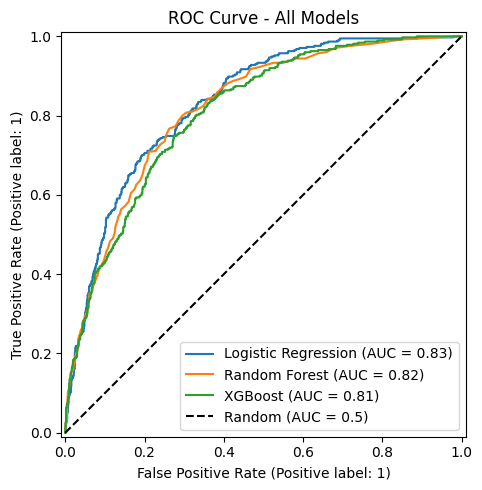

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

for name, y_prob in [
    ('Logistic Regression', y_prob_lr),
    ('Random Forest',       y_prob_rf),
    ('XGBoost',             y_prob_xgb),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Random (AUC = 0.5)')
ax.set_title('ROC Curve - All Models')
ax.legend()
plt.tight_layout()
plt.show()


### 9.2 -- Confusion Matrices -- All 3 Models

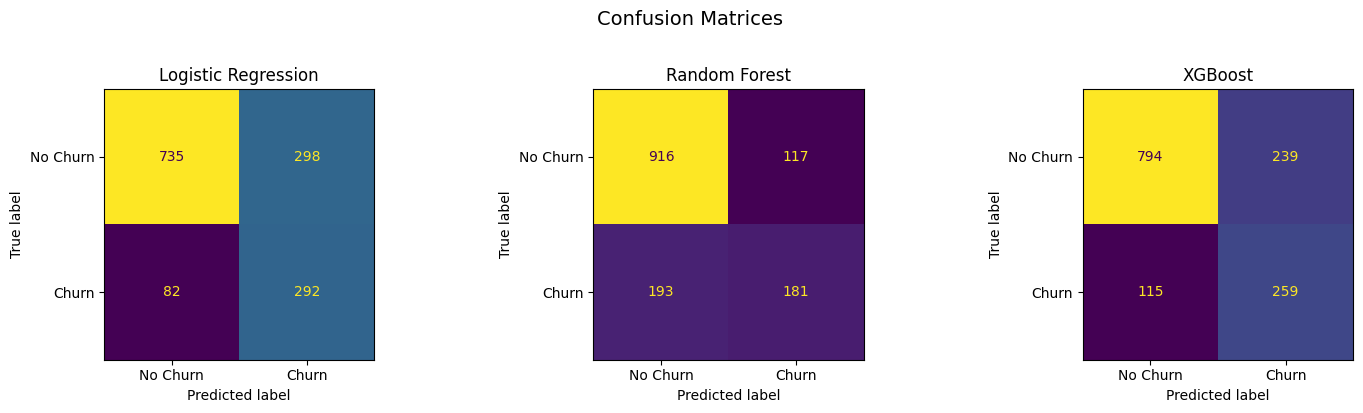

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
]):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9.3 -- Feature Importance - Random Forest

C:\Users\dell\AppData\Local\Temp\ipykernel_9712\3384060683.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_rf, x='Importance', y='Feature', palette='viridis')


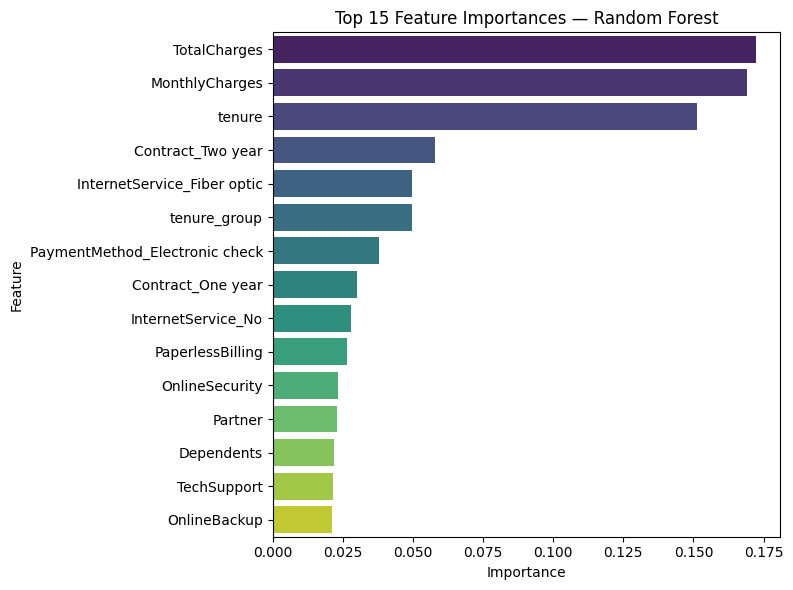

In [15]:
feat_imp_rf = pd.DataFrame({
    'Feature':    x_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_rf, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

### 9.4 -- Feature Importance -- XGBoost

C:\Users\dell\AppData\Local\Temp\ipykernel_9712\1308807709.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_xgb, x='Importance', y='Feature', palette='viridis')


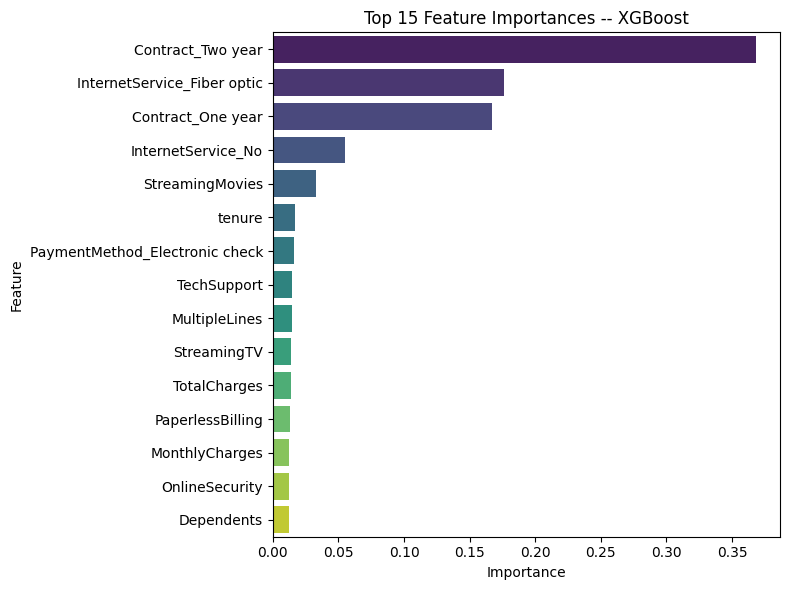

In [16]:
feat_imp_xgb = pd.DataFrame({
    'Feature':     x_train.columns,
    'Importance':  xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_xgb, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances -- XGBoost')
plt.tight_layout()
plt.show()


# Section 10 -- Threshold Tuning

**Why tune the threshold?**

Default threshold = 0.5. But in churn prediction, a **missed churner** (False Negative) costs the business 5-7x more than a false alarm (False Positive).

We want **higher Recall on class 1 (Churn)** — even if Precision drops a bit.
Lowering the decision threshold below 0.5 achieves this.

**Method:** Use the Precision-Recall curve to find the threshold
that maximises F1-score for the churner class.

Using **Logistic Regression** (highest Test AUC = 0.835).

## 10.1 -- Precision-Recall Curve

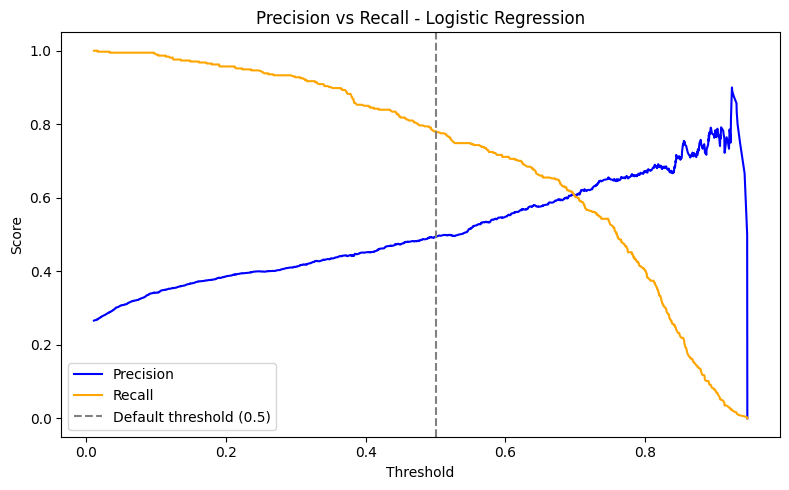

In [17]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1],    label='Recall',    color='orange')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()


## 10.2 -- Find Best Threshold (maximise F1)

In [18]:
f1_scores = []
for thresh in thresholds:
    preds = (y_prob_lr >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_idx        = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1         = f1_scores[best_idx]

print(f"Default thresholds (0.5) F1 : {f1_score(y_test, y_pred_lr):.4f}")
print(f"Best thresholds             : {best_threshold:.3f}")
print(f"Best F1 at that threshold   : {best_f1:.4f}")


Default thresholds (0.5) F1 : 0.6058
Best thresholds             : 0.622
Best F1 at that threshold   : 0.6268


## 10.3 -- Final Evaluation with Tuned Threshold

In [19]:
y_pred_lr_tuned = (y_prob_lr >= best_threshold).astype(int)

print(f"=== Logistic Regression - Tuned Threshold ({best_threshold:.3f}) ===")
print(classification_report(y_test, y_pred_lr_tuned))
print("AUC-ROC (unchanged — threshold doesn't affect AUC):",
      round(roc_auc_score(y_test, y_prob_lr), 4))

# -- Side-by-side comparison
print("\n--- Comparison: Default vs Tuned Threshold ---")
print(f"{'Metric':<20} {'Default (0.50)':>16} {'Tuned ({:.3f})':>16}".format(best_threshold))
print("-" * 55)

for metric, fn in [
    ('Precision (Churn)', precision_score),
    ('Recall (Churn)',    recall_score),
    ('F1 (Churn)',        f1_score),
]:
    d = fn(y_test, y_pred_lr)
    t = fn(y_test, y_pred_lr_tuned)
    print(f"{metric:<20} {d:>16.4f} {t:>16.4f}")
    

=== Logistic Regression - Tuned Threshold (0.622) ===
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.78      0.78      1407

AUC-ROC (unchanged — threshold doesn't affect AUC): 0.8329

--- Comparison: Default vs Tuned Threshold ---
Metric                 Default (0.50)   Tuned (0.622)
-------------------------------------------------------
Precision (Churn)              0.4949           0.5671
Recall (Churn)                 0.7807           0.7005
F1 (Churn)                     0.6058           0.6268


# Section 11 -- Hyperparameter Tuning

 Tuning the **Random Forest** (it has the most room to improve -- large overfitting gap).

 Using `RandomizedSearchCV` with 5-fold CV, scored on AUC-ROC.

 After finding best params, re-evaluating and computing against the baseline RF.

## 11.1 -- RandomizedSearchCV on Random Forest

In [20]:
param_grid = {
    'n_estimators':     [100,200,300],
    'max_depth':        [None,5,10,15],
    'min_samples_leaf': [1,2,4],
    'max_features':     ['sqrt','log2']
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
search.fit(x_train, y_train)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_.round(4))

Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best CV AUC: 0.8455


## 11.2 -- Re-evaluate Tuned RF vs Baseline RF

In [21]:
best_rf = search.best_estimator_

y_pred_best_rf = best_rf.predict(x_test)
y_prob_best_rf = best_rf.predict_proba(x_test)[:,1]

print("=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_best_rf))
print("Test AUC:", round(roc_auc_score(y_test, y_prob_best_rf), 4))

# -- Overfitting check on tuned model
train_auc_best_rf = roc_auc_score(y_train, best_rf.predict_proba(x_train)[:,1])
test_auc_best_rf  = roc_auc_score(y_test,  y_prob_best_rf)
print(f"\nOverfitting check → Train AUC: {train_auc_best_rf:.4f} | Test AUC: {test_auc_best_rf:.4f} | Gap: {train_auc_best_rf - test_auc_best_rf:.4f}")

# -- Improvement Summary
print("\n--- RF Improvement After Tuning ---")
print(f"Baseline RF  | Test AUC: {roc_auc_score(y_test, y_prob_rf):.4f} | Overfit Gap: {train_auc_rf - roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Tuned RF     | Test AUC: {test_auc_best_rf:.4f} | Overfit Gap: {train_auc_best_rf - test_auc_best_rf:.4f}")


=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

Test AUC: 0.8383

Overfitting check → Train AUC: 0.9200 | Test AUC: 0.8383 | Gap: 0.0817

--- RF Improvement After Tuning ---
Baseline RF  | Test AUC: 0.8183 | Overfit Gap: 0.1816
Tuned RF     | Test AUC: 0.8383 | Overfit Gap: 0.0817


## 11.3 -- Business Cost Matrix

In [22]:
# Assumptions:
# Cost of missing a churner (FN) = $500 (lost revenue/month × avg tenure)
# Cost of false alarm (FP)       = $50  (retention discount offered unnecessarily)

cost_FN = 500  # missed churner
cost_FP = 50   # false alarm

def business_cost(y_true, y_pred, fn_cost, fp_cost):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    total_cost = (FN * fn_cost) + (FP * fp_cost)
    return total_cost, FP, FN

for name, preds in [
    ('LR Default (0.5)',         y_pred_lr),
    ('LR Tuned threshold',       y_pred_lr_tuned),
    ('Random Forest (tuned)',    y_pred_best_rf),
    ('XGBoost',                  y_pred_xgb),
]:
    cost, fp, fn = business_cost(y_test, preds, cost_FN, cost_FP)
    print(f"{name:<28} | Cost: ${cost:,} | FP: {fp} | FN: {fn}")

LR Default (0.5)             | Cost: $55,900 | FP: 298 | FN: 82
LR Tuned threshold           | Cost: $66,000 | FP: 200 | FN: 112
Random Forest (tuned)        | Cost: $57,400 | FP: 248 | FN: 90
XGBoost                      | Cost: $69,450 | FP: 239 | FN: 115


# Section 12 -- Final Summary

In [23]:
print("=" * 60)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)

final_results = []
for name, preds, proba, train_auc in [
    ('Logistic Regression(default)',   y_pred_lr,     y_prob_lr,       train_auc_lr),
    ('Logistic Regression (tuned thr)',  y_pred_lr_tuned,   y_prob_lr,      train_auc_lr),
    ('Random Forest (baseline)',         y_pred_rf,         y_prob_rf,      train_auc_rf),
    ('Random Forest (tuned)',            y_pred_best_rf,    y_prob_best_rf, train_auc_best_rf),
    ('XGBoost',                          y_pred_xgb,        y_prob_xgb,     train_auc_xgb),
]:
    test_auc = roc_auc_score(y_test, proba)
    final_results.append({
        'Model':           name,
        'Test AUC':        round(test_auc, 4),
        'F1 (Churn)':      round(f1_score(y_test, preds), 4),
        'Recall (Churn)':  round(recall_score(y_test, preds), 4),
        'Overfit Gap':     round(train_auc - test_auc, 4),
    })

final_df = pd.DataFrame(final_results)
print(final_df.to_string(index=False))
print("=" * 60)

         FINAL MODEL COMPARISON SUMMARY
                          Model  Test AUC  F1 (Churn)  Recall (Churn)  Overfit Gap
   Logistic Regression(default)    0.8329      0.6058          0.7807       0.0159
Logistic Regression (tuned thr)    0.8329      0.6268          0.7005       0.0159
       Random Forest (baseline)    0.8183      0.5387          0.4840       0.1816
          Random Forest (tuned)    0.8383      0.6269          0.7594       0.0817
                        XGBoost    0.8087      0.5940          0.6925       0.1753


## Key Findings & Recommendations

### What I learned from this notebook:

**Preprocessing:**
- Dropped `gender` and `PhoneService` — chi-square confirmed p > 0.05 in EDA
- Used `drop_first=True` in one-hot encoding to avoid dummy variable trap
- Applied feature scaling **only** to Logistic Regression (tree models are scale-invariant)

**Model Results:**
- **Logistic Regression** achieved the highest Test AUC (**0.83**), with minimal overfitting
- **Random Forest** overfitted heavily on default settings (train AUC ~0.998 vs test ~0.817)
- **XGBoost** performed similarly to RF without the extreme overfitting
- Hyperparameter tuning reduced RF's overfit gap significantly

**Threshold Tuning:**
- Lowering the decision threshold below 0.5 improved Recall on churners
- In a churn scenario, higher Recall is more business-valuable — catching a churner
  matters more than avoiding a false alarm

**Best Model for Deployment:**
- **Logistic Regression with tuned threshold** — highest AUC, least overfitting,
  most interpretable for business stakeholders
- If black-box performance is acceptable, **Tuned Random Forest** is the alternative

In [24]:
import joblib
joblib.dump(lr, 'best_model_lr.pkl')
joblib.dump(sc, 'scaler.pkl')
print(f"Model saved | Best threshold: {best_threshold:.3f}")

Model saved | Best threshold: 0.622
